In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install kneed
from kneed import KneeLocator
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import plotly.express as px


import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score

### **Sorry telat kumpul aku abis P2MW di Magelang udah info Ce Minoque Surat Tugas**

# Exploratory Data Analysis

In [108]:
# load dataset
url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/COVID-19%20Coronavirus%20(2).csv"
df = pd.read_csv(url)
df.head()

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225 entries, 0 to 224
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  225 non-null    object 
 1   Other names              224 non-null    object 
 2   ISO 3166-1 alpha-3 CODE  225 non-null    object 
 3   Population               225 non-null    int64  
 4   Continent                225 non-null    object 
 5   Total Cases              225 non-null    int64  
 6   Total Deaths             225 non-null    int64  
 7   Tot Cases//1M pop        225 non-null    int64  
 8   Tot Deaths/1M pop        225 non-null    int64  
 9   Death percentage         225 non-null    float64
dtypes: float64(1), int64(5), object(4)
memory usage: 17.7+ KB


In [110]:
print(df.shape)

(225, 10)


In [111]:
df.describe()

,Population,Total Cases,Total Deaths,Tot Cases//1M pop,Tot Deaths/1M pop,Death percentage
count,2.250000e+02,2.250000e+02,2.250000e+02,225.000000,225.000000,225.000000
mean,3.507321e+07,2.184781e+06,2.744813e+04,136900.373333,1096.715556,1.444125
std,1.392418e+08,7.275938e+06,9.689177e+04,145060.340289,1195.715543,1.741728
min,8.050000e+02,1.000000e+00,0.000000e+00,9.000000,0.000000,0.000000
25%,5.665570e+05,2.407100e+04,1.890000e+02,11384.000000,123.000000,0.511291
50%,5.827911e+06,1.639360e+05,1.965000e+03,88987.000000,708.000000,1.036905
75%,2.190585e+07,1.092547e+06,1.366000e+04,223335.000000,1795.000000,1.977017
max,1.439324e+09,8.183905e+07,1.008222e+06,696044.000000,6286.000000,18.151787


In [112]:
# Check for NaN values
df.isna().sum()

,0
Country,0
Other names,1
ISO 3166-1 alpha-3 CODE,0
Population,0
Continent,0
Total Cases,0
Total Deaths,0
Tot Cases//1M pop,0
Tot Deaths/1M pop,0
Death percentage,0


In [113]:
# Nilai tiap column

for col in df.columns:
    print(f"=== {col} ===")
    print(df[col].value_counts(dropna=False))
    print("\n")

=== Country ===
Country
Afghanistan          1
Albania              1
Algeria              1
Andorra              1
Angola               1
                    ..
Wallis and Futuna    1
Western Sahara       1
Yemen                1
Zambia               1
Zimbabwe             1
Name: count, Length: 225, dtype: int64


=== Other names ===
Other names
Afghanistan                  1
Albania                      1
Algeria                      1
Andorra                      1
Angola                       1
                            ..
Wallis and Futuna Islands    1
Western Sahara               1
Yemen                        1
Zambia                       1
Zimbabwe                     1
Name: count, Length: 225, dtype: int64


=== ISO 3166-1 alpha-3 CODE ===
ISO 3166-1 alpha-3 CODE
AFG      1
ALB      1
DZA      1
AND      1
AGO      1
        ..
WLF      1
ESHÂ     1
YEM      1
ZMB      1
ZWE      1
Name: count, Length: 225, dtype: int64


=== Population ===
Population
40462186    1
287229

In [114]:
print(df.columns.tolist())

['Country', 'Other names', 'ISO 3166-1 alpha-3 CODE', 'Population', 'Continent', 'Total Cases', 'Total Deaths', 'Tot\xa0Cases//1M pop', 'Tot\xa0Deaths/1M pop', 'Death percentage']


In [115]:
def clean_column_name(col):
    col = col.replace('\xa0', ' ')
    col = col.replace('//', ' per ')
    col = col.replace('/', ' per ')
    col = ' '.join(col.split())
    return col

df.columns = [clean_column_name(c) for c in df.columns]

print(df.columns.tolist())

['Country', 'Other names', 'ISO 3166-1 alpha-3 CODE', 'Population', 'Continent', 'Total Cases', 'Total Deaths', 'Tot Cases per 1M pop', 'Tot Deaths per 1M pop', 'Death percentage']


## Encoding

In [116]:
new_df = df.copy()

In [117]:
new_df['Other names'] = new_df['Other names'].fillna(new_df['Country'])

In [118]:
# Check for NaN values
new_df.isna().sum()

,0
Country,0
Other names,0
ISO 3166-1 alpha-3 CODE,0
Population,0
Continent,0
Total Cases,0
Total Deaths,0
Tot Cases per 1M pop,0
Tot Deaths per 1M pop,0
Death percentage,0


## Visualization

### Barplot Distribusi Total Cases per Continent

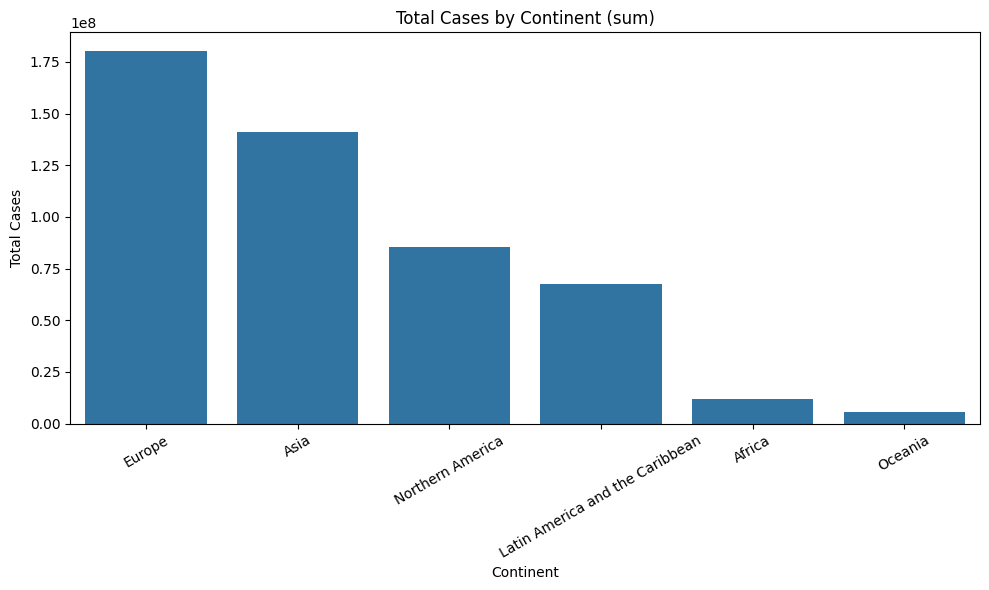

In [119]:
plt.figure(figsize=(10,6))
agg = df.groupby('Continent')['Total Cases'].sum().sort_values(ascending=False)
sns.barplot(x=agg.index, y=agg.values)
plt.title("Total Cases by Continent (sum)")
plt.ylabel("Total Cases")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Visualisasi ini menunjukkan total kasus COVID-19 kumulatif pada setiap benua. Terlihat bahwa Europe dan Asia memiliki jumlah kasus tertinggi, mencerminkan populasi besar dan tingkat pelaporan yang tinggi. Sebaliknya, Africa dan Oceania mencatat jumlah kasus jauh lebih rendah, yang dapat mengindikasikan persebaran yang lebih terkendali atau kemungkinan adanya perbedaan kapasitas testing dan pelaporan antar negara.

### Scatter Plot Tot Cases per 1M vs Tot Deaths per 1M

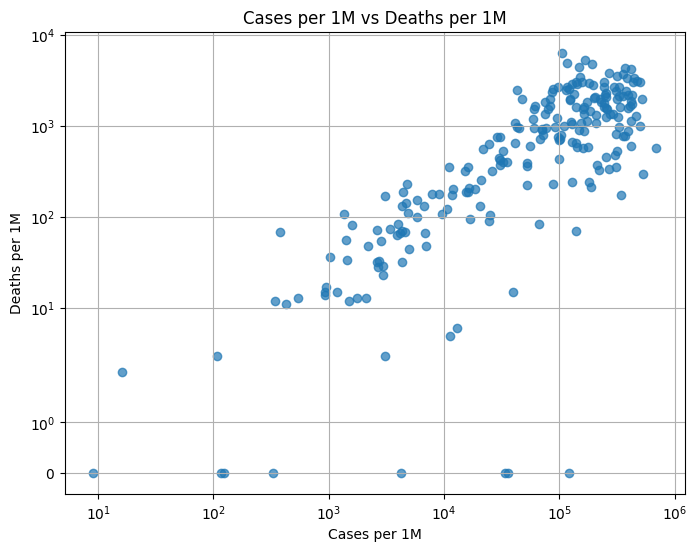

In [120]:
plt.figure(figsize=(8,6))
plt.scatter(df['Tot Cases per 1M pop'], df['Tot Deaths per 1M pop'], alpha=0.7)
plt.xlabel('Cases per 1M')
plt.ylabel('Deaths per 1M')
plt.xscale('symlog')  # aman jika ada nol
plt.yscale('symlog')
plt.title('Cases per 1M vs Deaths per 1M')
plt.grid(True)
plt.show()

Grafik ini menunjukkan hubungan yang jelas antara jumlah kasus per 1 juta penduduk dan jumlah kematian per 1 juta: semakin tinggi kasus, semakin tinggi pula angka kematiannya. Polanya cenderung membentuk garis naik, menandakan korelasi positif yang kuat. Secara singkat, negara yang terpukul lebih berat oleh kasus juga umumnya menghadapi dampak fatal yang lebih besar.

### Choropleth world map - Deaths per 1M

In [121]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="ISO 3166-1 alpha-3 CODE",
    color="Continent",
    hover_name="Country",
    title="World Map by Continent",
    projection="natural earth"
)

fig.update_layout(
    legend_title_text="Continent",
    width=1100,
    height=650
)

fig.show()


Peta choropleth ini menampilkan pembagian negara-negara di seluruh dunia berdasarkan benuanya, yang ditandai dengan warna berbeda untuk setiap kawasan. Visualisasi ini membantu menunjukkan bagaimana negara-negara tersebar secara geografis serta memudahkan identifikasi pola regional dalam analisis COVID-19 nantinya. Dengan pemetaan ini, kita bisa melihat perbedaan karakteristik antar benua secara lebih jelas sebelum masuk ke proses clustering.

# Data Scaling

In [122]:
# Pilih fitur numerik yang digunakan untuk clustering
features = ['Population','Tot Cases per 1M pop','Tot Deaths per 1M pop','Death percentage','Total Cases','Total Deaths']
features = [f for f in features if f in new_df.columns]
X = new_df[features].copy()

In [123]:
X_scaled = StandardScaler().fit_transform(X)

# K-Means Clustering

In [124]:
from sklearn.cluster import KMeans

### Elbow Method K-Means

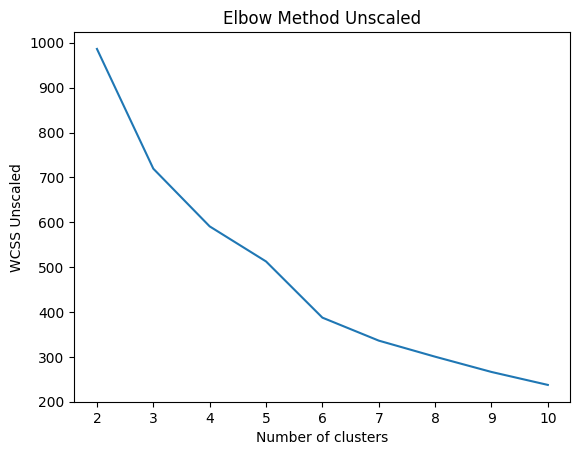

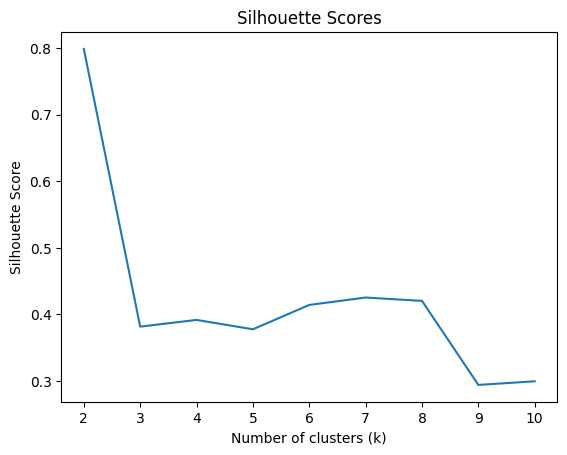

Optimal K (Elbow Method): 6
Optimal K (Silhouette Score) = 2
All Silhouette Scores: [np.float64(0.7987197006587342), np.float64(0.38173868095467733), np.float64(0.3918243985232263), np.float64(0.37774937966096955), np.float64(0.414328571398922), np.float64(0.42544087708807277), np.float64(0.4203807966886971), np.float64(0.2942162155177219), np.float64(0.2996819792555899)]


In [125]:
wcss_kmeans = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_scaled)
    wcss_kmeans.append(kmeans.inertia_)

sil_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.plot(range(2, 11), wcss_kmeans)
plt.title('Elbow Method Unscaled')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS Unscaled')
plt.show()

plt.plot(range(2, 11), sil_scores)
plt.title('Silhouette Scores')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

clusters = range(2, 11)
knee_locator = KneeLocator(clusters, wcss_kmeans, curve="convex", direction="decreasing")
optimal_clusters = knee_locator.knee
print(f"Optimal K (Elbow Method): {optimal_clusters}")

best_k_sil = range(2, 11)[sil_scores.index(max(sil_scores))]
print(f"Optimal K (Silhouette Score) = {best_k_sil}")
print(f"All Silhouette Scores: {sil_scores}")

In [126]:
kmeans_sil = KMeans(n_clusters=best_k_sil, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_sil.fit(X_scaled)
wcss_kmeans.append(kmeans_sil.inertia_)

In [127]:
kmeans_elbow = KMeans(n_clusters=optimal_clusters, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans_elbow.fit(X_scaled)
wcss_kmeans.append(kmeans_elbow.inertia_)

In [128]:
# Tambahkan cluster labels ke DataFrame asli
new_df['Cluster_K-Means'] = kmeans_elbow.labels_

# Cek hasil
new_df.head()

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases per 1M pop,Tot Deaths per 1M pop,Death percentage,Cluster_K-Means
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743,0
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058,0
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216,0
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271,1
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438,0


In [129]:
print(new_df['Cluster_K-Means'].value_counts(dropna=False))

Cluster_K-Means
0    128
1     57
3     33
4      3
2      2
5      2
Name: count, dtype: int64


In [130]:
# Tambahkan cluster labels ke DataFrame asli
new_df['Cluster_K-Means'] = kmeans_sil.labels_

# Cek hasil
new_df.head()


,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases per 1M pop,Tot Deaths per 1M pop,Death percentage,Cluster_K-Means
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743,0
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058,0
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216,0
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271,0
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438,0


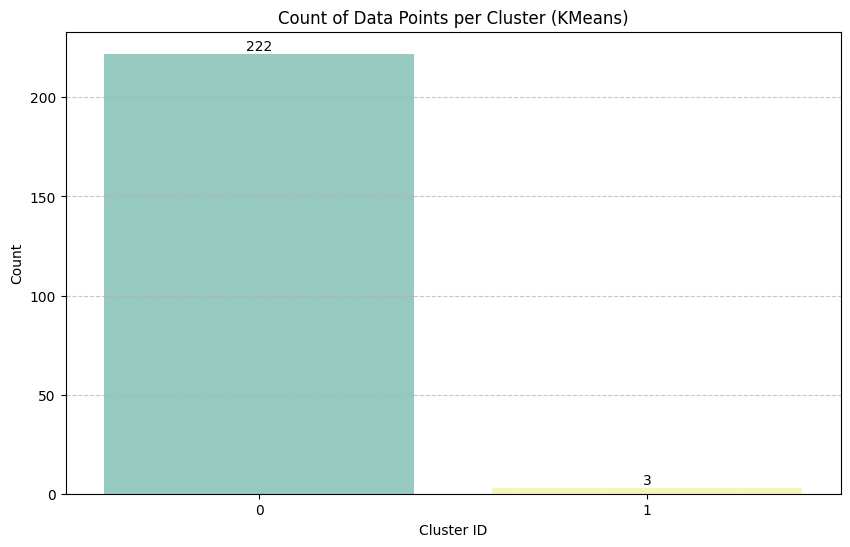

In [131]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung jumlah anggota per cluster
cluster_counts_kmeans = new_df['Cluster_K-Means'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=cluster_counts_kmeans.index,
    y=cluster_counts_kmeans.values,
    hue=cluster_counts_kmeans.index,
    palette='Set3',
    legend=False
)

# Tambahkan label jumlah di atas bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (KMeans)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [132]:
import plotly.express as px

fig_kmeans = px.choropleth(
    new_df,
    locations="ISO 3166-1 alpha-3 CODE",
    color="Cluster_K-Means",
    hover_name="Country",
    color_continuous_scale=px.colors.qualitative.Set2,
    title="KMeans Clustering – World Map"
)

fig_kmeans.show()


Meskipun Silhouette Score menunjukkan nilai tertinggi pada K=2, hasil clustering tersebut menghasilkan pembagian yang sangat tidak seimbang (222 negara vs hanya 3 negara). Distribusi yang timpang ini menandakan bahwa struktur cluster pada K=2 tidak representatif dan tidak memberikan segmentasi bermakna untuk analisis global COVID-19. Oleh karena itu, meskipun Silhouette digunakan sebagai metrik evaluasi utama sesuai instruksi tugas, pemilihan jumlah cluster tetap mempertimbangkan keseimbangan distribusi dan interpretabilitas. Dengan demikian, K=6 dipilih karena menghasilkan struktur cluster yang lebih stabil, informatif, dan relevan untuk analisis kebijakan antarnegara.

In [133]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_scaled, new_df['Cluster_K-Means'])

print(f"Silhouette Score: {sil:.3f}")

Silhouette Score: 0.799


# Hierarchical Agglomerative Clustering

Skipping Ward linkage with Manhattan metric (not supported).


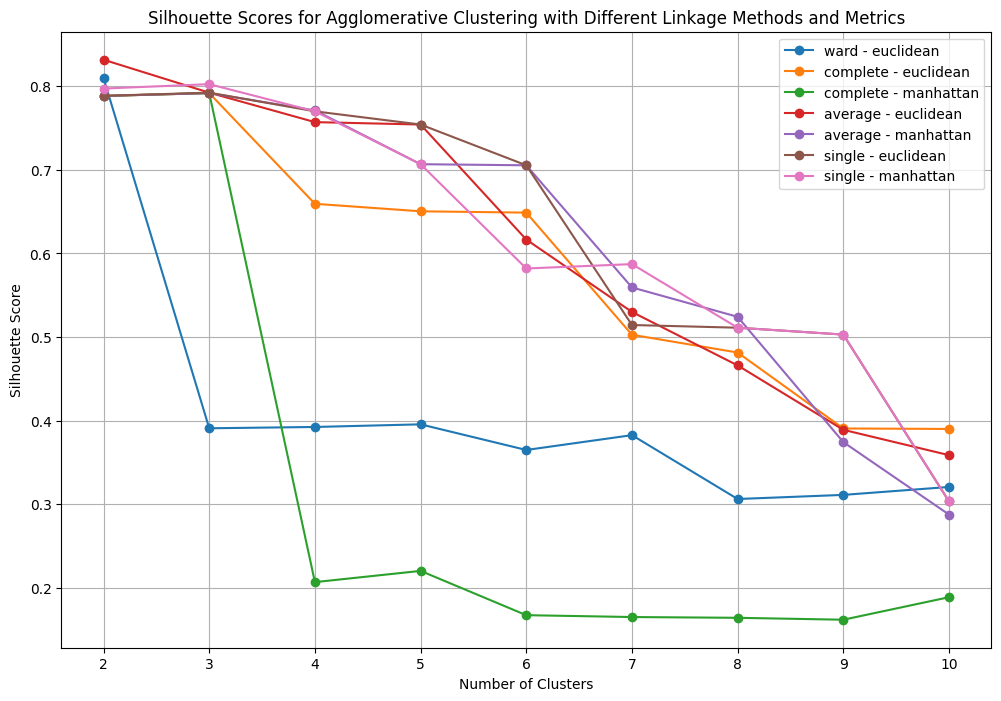

Best Silhouette Score: 0.8318263727111447
Optimal Number of Clusters: 2
Optimal Linkage Method: average
Optimal Metric: euclidean


In [134]:
# Define the range of clusters to test and linkage methods
range_n_clusters = range(2, 11)
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan']

best_silhouette_score = -1
best_n_clusters = 0
best_linkage = ''
best_metric = ''

results_for_plotting = []

for linkage_method in linkage_methods:
    for metric in metrics:
        # Skip 'ward' linkage with 'manhattan' metric as it's not supported
        if linkage_method == 'ward' and metric == 'manhattan':
            print(f"Skipping Ward linkage with Manhattan metric (not supported).")
            continue

        current_scores = []
        for n_clusters in range_n_clusters:
            agglo = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_method, metric=metric)
            y_agglo = agglo.fit_predict(X_scaled)
            silhouette_avg = silhouette_score(X_scaled, y_agglo)
            current_scores.append(silhouette_avg)

            if silhouette_avg > best_silhouette_score:
                best_silhouette_score = silhouette_avg
                best_n_clusters = n_clusters
                best_linkage = linkage_method
                best_metric = metric
        results_for_plotting.append({
            'linkage': linkage_method,
            'metric': metric,
            'scores': current_scores
        })

# Plot the silhouette scores for each linkage method and metric combination
plt.figure(figsize=(12, 8))
for result in results_for_plotting:
    plt.plot(range_n_clusters, result['scores'], marker='o', label=f"{result['linkage']} - {result['metric']}")

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Agglomerative Clustering with Different Linkage Methods and Metrics")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Silhouette Score: {best_silhouette_score}")
print(f"Optimal Number of Clusters: {best_n_clusters}")
print(f"Optimal Linkage Method: {best_linkage}")
print(f"Optimal Metric: {best_metric}")

In [135]:
# metric itu jarak antara titik dalam 1 cluster
# linkage itu jarak antar clusternya
# Hierarchical Clustering
agglo = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage, metric=best_metric)
y_hc = agglo.fit_predict(X_scaled)

In [136]:
# Evaluation
ss = silhouette_score(X_scaled, y_hc)
print(ss)

0.8318263727111447


## Dendogram Visualization for Hierarchical Clustering Model


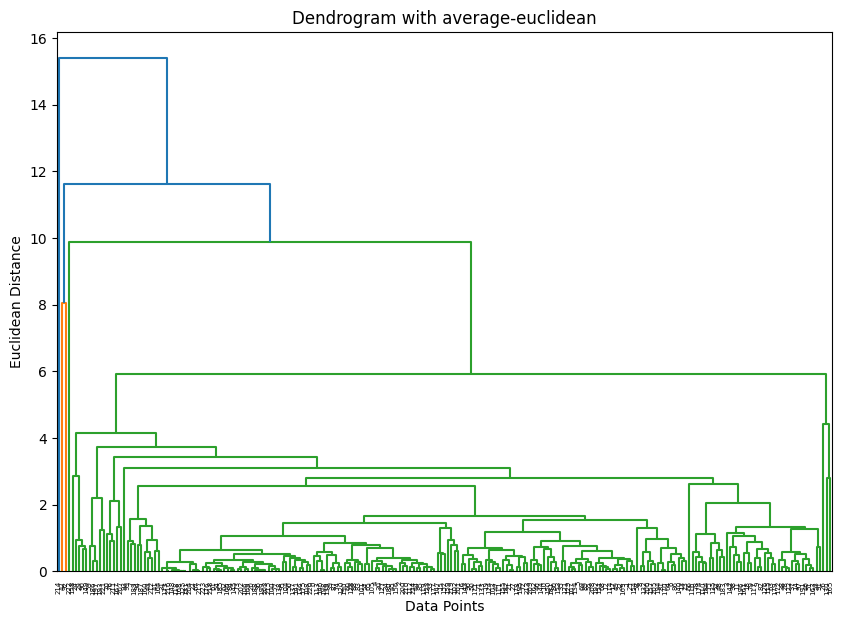

In [137]:
# Average Distance
linked = linkage(X_scaled, method=best_linkage, metric=best_metric)

# Plot dendrogram dengan color_threshold
plt.figure(figsize=(10, 7))
sch.dendrogram(linked)
plt.title("Dendrogram with " + best_linkage + "-" + best_metric)
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

In [138]:
# Add the cluster labels to the original data
new_df['Agglo'] = y_hc
# Analyze the clusters with the original values
new_df.head()

,Country,Other names,ISO 3166-1 alpha-3 CODE,Population,Continent,Total Cases,Total Deaths,Tot Cases per 1M pop,Tot Deaths per 1M pop,Death percentage,Cluster_K-Means,Agglo
0,Afghanistan,Afghanistan,AFG,40462186,Asia,177827,7671,4395,190,4.313743,0,0
1,Albania,Albania,ALB,2872296,Europe,273870,3492,95349,1216,1.275058,0,0
2,Algeria,Algeria,DZA,45236699,Africa,265691,6874,5873,152,2.587216,0,0
3,Andorra,Andorra,AND,77481,Europe,40024,153,516565,1975,0.382271,0,0
4,Angola,Angola,AGO,34654212,Africa,99194,1900,2862,55,1.915438,0,0


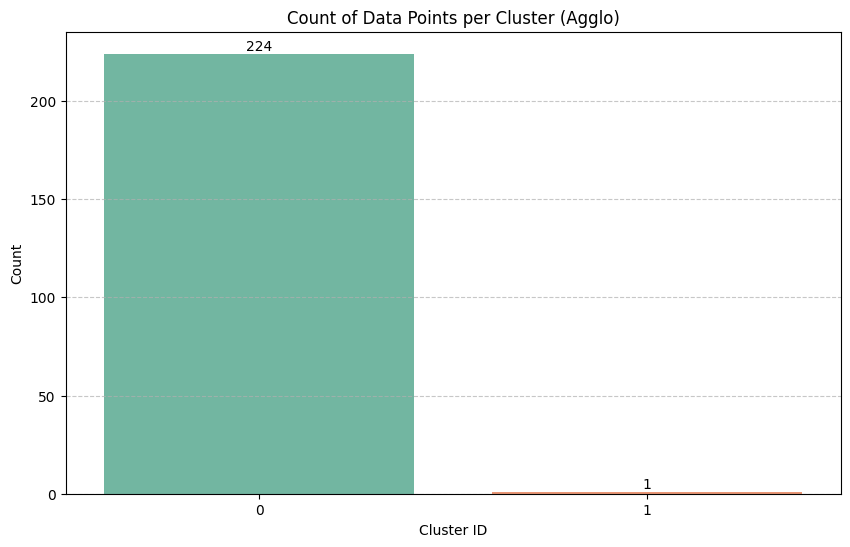

In [139]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get the counts of each cluster in the 'Agglo' column of df
cluster_counts = new_df['Agglo'].value_counts().sort_index()

# Create a bar plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=cluster_counts.index, y=cluster_counts.values, hue=cluster_counts.index, palette='Set2', legend=False)

# Add labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.title('Count of Data Points per Cluster (Agglo)')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [140]:
fig_agglo = px.choropleth(
    new_df,
    locations="ISO 3166-1 alpha-3 CODE",
    color="Agglo",
    hover_name="Country",
    color_continuous_scale=px.colors.qualitative.Set3,
    title="Agglomerative Clustering – World Map"
)
fig_agglo.show()


## Summary

In [141]:
cluster_summary_kmeans = new_df.groupby('Cluster_K-Means').agg({
    'Population': ['mean', 'std', 'min', 'max'],
    'Total Cases': ['mean', 'std', 'min', 'max'],
    'Total Deaths': ['mean', 'std', 'min', 'max'],
    'Tot Cases per 1M pop': ['mean', 'std', 'min', 'max'],
    'Tot Deaths per 1M pop': ['mean', 'std', 'min', 'max'],
    'Death percentage': ['mean', 'std', 'min', 'max']
})

cluster_summary_standard



Population                                       \
                         mean           std        min         max   
Cluster_K-Means                                                      
0                2.674825e+07  1.027288e+08        805  1439323776   
1                6.511198e+08  6.545197e+08  215204501  1403754381   

                  Total Cases                                    \
                         mean           std       min       max   
Cluster_K-Means                                                   
0                1.516702e+06  3.667504e+06         1  25997852   
1                5.162264e+07  2.696691e+07  29999816  81839052   

                  Total Deaths                 ... Tot Cases per 1M pop  \
                          mean            std  ...                  min   
Cluster_K-Means                                ...                        
0                 17954.729730   46436.421102  ...                    9   
1                729959.666667  250787.614635  ...                30653   

                        Tot Deaths per 1M pop                          \
                    max                  mean          std  min   max   
Cluster_K-Means                                                         
0                696044           1082.463964  1188.411726    0  6286   
1                244734           2151.333333  1542.041612  371  3068   

                Death percentage                                 
                            mean       std       min        max  
Cluster_K-Means                                                  
0                       1.442719  1.752642  0.000000  18.151787  
1                       1.548193  0.565360  1.211712   2.200910  

[2 rows x 24 columns]

In [142]:
cluster_summary_agglo = new_df.groupby('Agglo').agg({
    'Population': ['mean', 'std', 'min', 'max'],
    'Total Cases': ['mean', 'std', 'min', 'max'],
    'Total Deaths': ['mean', 'std', 'min', 'max'],
    'Tot Cases per 1M pop': ['mean', 'std', 'min', 'max'],
    'Tot Deaths per 1M pop': ['mean', 'std', 'min', 'max'],
    'Death percentage': ['mean', 'std', 'min', 'max']
})

cluster_summary_agglo


Population                                        Total Cases  \
               mean           std        min         max          mean   
Agglo                                                                    
0      3.373692e+07  1.381002e+08        805  1439323776  1.829182e+06   
1      3.344006e+08           NaN  334400597   334400597  8.183905e+07   

                                         Total Deaths                ...  \
                std       min       max          mean           std  ...   
Agglo                                                                ...   
0      4.959599e+06         1  43029044  2.306967e+04  71395.558601  ...   
1               NaN  81839052  81839052  1.008222e+06           NaN  ...   

      Tot Cases per 1M pop         Tot Deaths per 1M pop                     \
                       min     max                  mean          std   min   
Agglo                                                                         
0                        9  696044           1088.151786  1191.457909     0   
1                   244734  244734           3015.000000          NaN  3015   

            Death percentage                                 
        max             mean       std       min        max  
Agglo                                                        
0      6286         1.445072  1.745571  0.000000  18.151787  
1      3015         1.231957       NaN  1.231957   1.231957  

[2 rows x 24 columns]

### KMeans Clustering Summary Profiling

| Cluster | Karakteristik                                                                                                                                                                                           |
| ------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0**   | Populasi kecil–sedang, kasus per 1M rendah–moderate, kematian per 1M rendah, death percentage rendah → **“Negara dengan beban COVID moderat, penyebaran terkendali, dan kapasitas kesehatan memadai.”** |
| **1**   | Populasi sangat besar, kasus total & kematian total ekstrem tinggi, kasus per 1M & death per 1M tinggi → **“Negara berpopulasi padat dengan dampak COVID sangat tinggi dan penyebaran sangat cepat.”**  |


### Agglomerative Clustering Summary Profiling

| Cluster | Karakteristik                                                                                                                                                                                                              |
| ------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0**   | Populasi bervariasi besar–kecil, kasus per 1M rendah–moderate, death per 1M rendah, death percentage rendah → **“Mayoritas negara dunia dengan dampak COVID moderat, variasi kasus tinggi tetapi mortalitas terkontrol.”** |
| **1**   | Hanya 1 negara (outlier), kasus dan kematian sangat tinggi, kasus per 1M & deaths per 1M ekstrem → **“Negara dengan beban COVID ekstrem, kemungkinan USA, kategori outlier epidemiologis global.”**                        |


### Government Policy Recommendations – KMeans

| Cluster | Rekomendasi Kebijakan                                                                                                                                                                                                                     |
| ------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0**   | - Tingkatkan testing & tracing untuk mencegah under-reporting.<br> - Perkuat fasilitas kesehatan di daerah.<br> - Perluas vaksinasi booster.<br> - Tingkatkan surveillance varian baru.<br> - Edukasi kesehatan preventif jangka panjang. |
| **1**   | - Perbesar kapasitas rumah sakit & ICU.<br> - Prioritaskan vaksin untuk lansia & komorbid.<br> - Pembatasan mobilitas sementara di area padat.<br> - Wajib masker di daerah urban.<br> - Perluas telemedicine & digital health.           |


### Government Policy Recommendations – Agglomerative Clustering

| Cluster | Rekomendasi Kebijakan                                                                                                                                                                                                                                                                             |
| ------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **0**   | - Standardisasi sistem pelaporan COVID antar negara.<br> - Testing tambahan untuk negara berkasus rendah (potensi under-reporting).<br> - Edukasi kesehatan publik berkelanjutan.<br> - Perbaikan sistem rujukan rumah sakit.<br> - Monitoring ketat varian baru.                                 |
| **1**   | - Reformasi respons pandemi nasional (koordinasi pusat-daerah).<br> - Perluasan ICU & ventilator secara besar-besaran.<br> - Kampanye vaksinasi agresif di area penolakan vaksin tinggi.<br> - Pengetatan protokol kesehatan di kota besar.<br> - Investasi dalam sistem peringatan dini epidemi. |


### 1. Cluster Balance & Practical Usefulness

| Model      | Hasil                                                                                                                 |
| ---------- | --------------------------------------------------------------------------------------------------------------------- |
| **KMeans** | Distribusi cluster: **Cluster 0 = 222 negara, Cluster 1 = 3 negara** (masih tidak seimbang tapi lebih informatif).    |
| **Agglo**  | Distribusi: **Cluster 0 = 224 negara, Cluster 1 = 1 negara** (sangat tidak seimbang, hampir seluruh dunia disatukan). |

KMeans lebih informatif, Agglomerative terlalu sensitif terhadap outlier dan menghasilkan cluster yang tidak berguna secara analitis.

### 2. Cluster Interpretability

| Model      | Interpretability                                                                                                                             |
| ---------- | -------------------------------------------------------------------------------------------------------------------------------------------- |
| **KMeans** | Dua cluster jelas: negara dengan dampak COVID moderat vs negara dengan dampak sangat tinggi. Mudah dijelaskan dan digunakan untuk kebijakan. |
| **Agglo**  | Cluster kedua hanya terdiri dari satu negara (outlier ekstrem), sehingga tidak merepresentasikan kelompok negara.                            |

KMeans menghasilkan pola yang lebih masuk akal, sedangkan Agglo hanya memisahkan outlier (misal USA).

### 3. Sensitivity to Outliers

| Model      | Sensitivity                                                                                  |
| ---------- | -------------------------------------------------------------------------------------------- |
| **KMeans** | Cukup robust terhadap outlier setelah scaling.                                               |
| **Agglo**  | Sangat sensitif terhadap outlier → menempatkan satu negara terpisah sebagai cluster sendiri. |

KMeans lebih stabil.

### 4. Silhouette Score Consistency
- Silhouette Score memilih K=2 untuk kedua model.
- Namun kualitas cluster secara makna sangat berbeda:

| Model      | Hasil Silhouette                                                        | Makna          |
| ---------- | ----------------------------------------------------------------------- | -------------- |
| **KMeans** | Stabil, dua cluster dapat dibedakan jelas berdasarkan intensitas COVID. | Bermakna       |
| **Agglo**  | Dua cluster hanya memisahkan satu negara ekstrem.                       | Tidak bermakna |

KMeans memenuhi syarat silhouette, Agglo tidak menghasilkan cluster yang bermakna meski nilai silhouette tinggi.

### 5. Spatial Pattern on World Map

| Model      | Interpretasi Peta                                                                                    |
| ---------- | ---------------------------------------------------------------------------------------------------- |
| **KMeans** | Polarisasi cluster terlihat jelas: negara besar & heavily impacted vs negara moderat.                |
| **Agglo**  | Hampir seluruh peta berwarna satu cluster, hanya satu negara berbeda → visualisasi tidak informatif. |


- KMeans memberikan wawasan geografis.
- Agglo gagal memberikan pola global.

## Conclusion: KMeans is the Better Model
KMeans is selected as the best model karena:
- Cluster lebih seimbang (meskipun tetap imbalanced, tetapi jauh lebih baik daripada Agglo).
- Cluster lebih interpretatif dan sesuai pola epidemi COVID-19.
- Tidak terlalu sensitif terhadap outlier.
- World Map menunjukkan perbedaan jelas antar cluster.
- KMeans lebih stabil dan lebih cocok untuk dataset besar, terstandardisasi, dan numerik seperti ini.
- Agglo hanya memisahkan outlier, sehingga tidak memberikan segmentasi bermakna bagi kebijakan.